In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("height-weight.csv")

In [3]:
df

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160
5,78,162
6,80,163
7,90,175
8,95,182
9,78,170


Text(0, 0.5, 'Height')

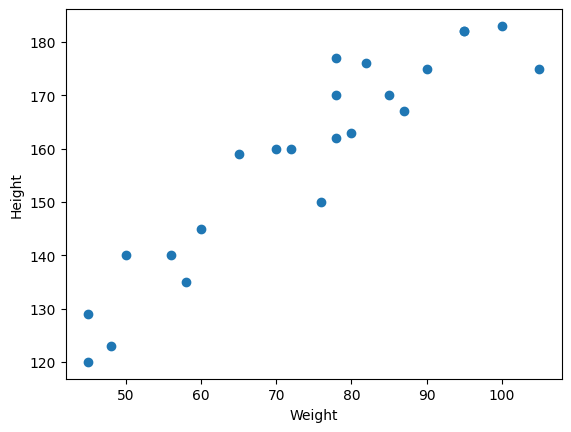

In [6]:
plt.scatter(df.Weight , df.Height)
plt.xlabel("Weight")
plt.ylabel("Height")

In [8]:
X=df[["Weight"]]
y=df["Height"]

In [9]:
from sklearn.model_selection import train_test_split

In [11]:
x_train, x_test,y_train,y_test=train_test_split(X,y,test_size=.25, random_state=1)

In [12]:
x_train

,Weight
10,82
4,70
2,48
18,76
6,80
7,90
1,58
14,85
0,45
15,78


In [13]:
x_test

,Weight
20,45
17,65
3,60
13,100
19,87
16,50


In [14]:
y_train

10    176
4     160
2     123
18    150
6     163
7     175
1     135
14    170
0     120
15    177
22    160
21    140
9     170
8     182
12    175
11    182
5     162
Name: Height, dtype: int64

In [15]:
y_test

20    129
17    159
3     145
13    183
19    167
16    140
Name: Height, dtype: int64

In [16]:
x_train.shape

(17, 1)

In [17]:
y_train.shape

(17,)

SCALLING

STANDARDIZATION >> FIT_TRANSFORM>>TRAIN , TRANSFORM>>TEST

ALWAYS PERFORM SCALING AFTER TRAIN TEST SPILT

In [18]:
from sklearn.preprocessing import StandardScaler

In [19]:
scaler=StandardScaler()

In [20]:
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)



In [21]:
x_test

array([[-1.91781863],
       [-0.678164  ],
       [-0.98807766],
       [ 1.49123159],
       [ 0.68545609],
       [-1.60790497]])

In [22]:
x_train

array([[ 0.37554243],
       [-0.36825034],
       [-1.73187043],
       [ 0.00364604],
       [ 0.25157697],
       [ 0.87140428],
       [-1.11204312],
       [ 0.56149062],
       [-1.91781863],
       [ 0.12761151],
       [-0.24428488],
       [-1.23600858],
       [ 0.12761151],
       [ 1.18131794],
       [ 1.80114525],
       [ 1.18131794],
       [ 0.12761151]])

Y/TARGET VARIABLE SHOULD NOT BE SCALLED

AVOID SACLING CATAGORICAL DATA

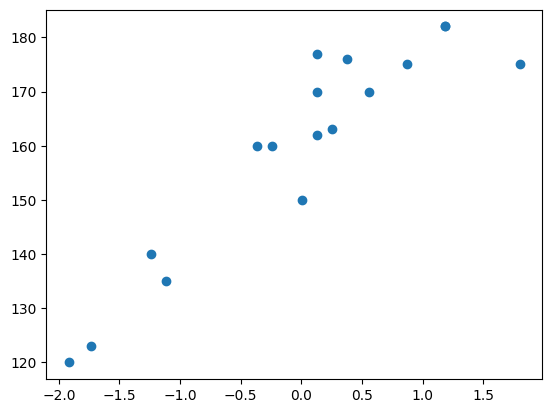

In [23]:
# scaling is optional >> why ? >> it doesn't change the distribution of data

plt.scatter(x_train,y_train)

In [ ]:
from sklearn.linear_model import LinearRegression


#linear regression parameters:
#fit_intercept >> The best fit line will have intercept, by default it is true
#copy__X >> copy the original X_train and then build the model, dont modify the original data,by default>>true
#n_jobs >> processor you want to use
#positive>> you want all of your coefficient to be positive


#After building the model, you have attributes of the mode
#coef
#intercept

In [28]:
regressor=LinearRegression()

In [29]:
regressor

LinearRegression()

In [ ]:
#TRAINING OF THE DATA
regressor.fit(x_train,y_train)

LinearRegression()

In [31]:
print("The slope of the model is ", regressor.coef_)
print("The intercept of the model is ", regressor.intercept_)


The slope of the model is  [17.7307072]
The intercept of the model is  160.0


# PREDICTION ON TRAIN DATA

prediction height output= INTERCEPT + COEF_(WEIGHT)

Y_PRED_TRAIN = 160.0+17.74*(X_TRAIN)

# Prediction on test data

prediction height output= INTERCEPT + COEF_(WEIGHT)

Y_PRED_Test = 160.0+17.74*(X_test)

In [32]:
regressor.predict(x_train)

array([166.65863288, 153.47066096, 129.29271243, 160.06464692,
       164.46063756, 175.45061417, 140.28268904, 169.95562586,
       125.99571945, 162.26264224, 155.66865628, 138.08469371,
       162.26264224, 180.94560247, 191.93557907, 180.94560247,
       162.26264224])

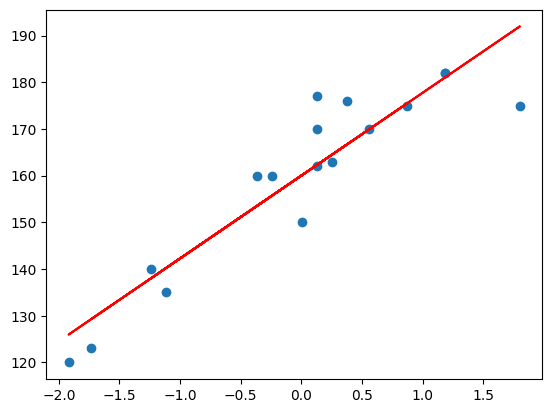

In [33]:
plt.scatter(x_train,y_train)
plt.plot(x_train,regressor.predict(x_train),'r')

In [35]:
y_pred_test=regressor.predict(x_test)

In [36]:
y_pred_test

array([125.99571945, 147.97567266, 142.48068436, 186.44059077,
       172.15362118, 131.49070775])

In [37]:
y_pred_test,y_test

(array([125.99571945, 147.97567266, 142.48068436, 186.44059077,
        172.15362118, 131.49070775]),
 20    129
 17    159
 3     145
 13    183
 19    167
 16    140
 Name: Height, dtype: int64)

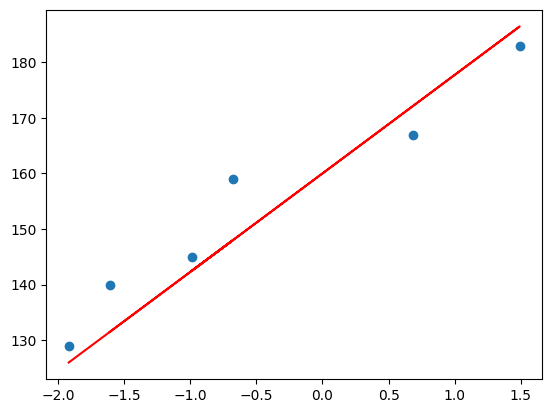

In [38]:
plt.scatter(x_test,y_test)
plt.plot(x_test,y_pred_test,'r')


In [ ]:
#performance metrics

In [39]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [40]:
mse=mean_squared_error(y_test,y_pred_test)
mae=mean_absolute_error(y_test,y_pred_test)
rmse=np.sqrt(mse)

print(mse , mae, rmse)

41.285662830455514 5.608571289304838 6.425392037102134


In [ ]:
# R square => 1-SSR/SST

In [41]:
from sklearn.metrics import r2_score

In [43]:
score=r2_score(y_test,y_pred_test)

In [44]:
score

0.8721036174256606

In [ ]:
# Adjusted Rsquare
#R2 = 1 – [(1-R2)*(n-1)/(n-k-1)] #n is no of obs, k is no predictor varaiables

In [ ]:
1-(1-score)*(len(y_test)-1)/(len(y_test) - x_test.shape[1] -1)

# adjusted r squared will be always lesser than rsquare

0.8401295217820757

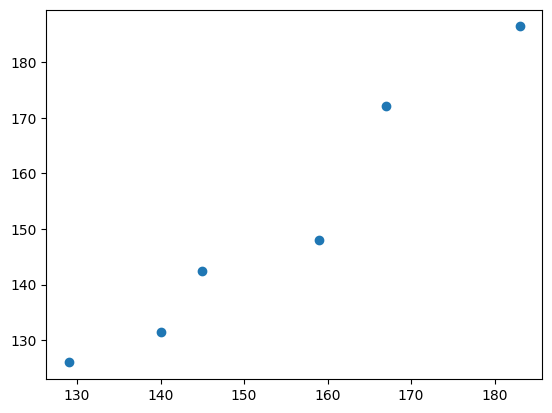

In [46]:
#assumption
#X-y should have linear relationship
# Observation should have no relation
# error should have constant variance
#error should be normally distribute

plt.scatter(y_test,y_pred_test)

In [47]:
error= y_test-y_pred_test
error

20     3.004281
17    11.024327
3      2.519316
13    -3.440591
19    -5.153621
16     8.509292
Name: Height, dtype: float64

C:\Users\tanmo\AppData\Local\Temp\ipykernel_25848\2693757243.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(error, kde=True)


<Axes: xlabel='Height', ylabel='Density'>

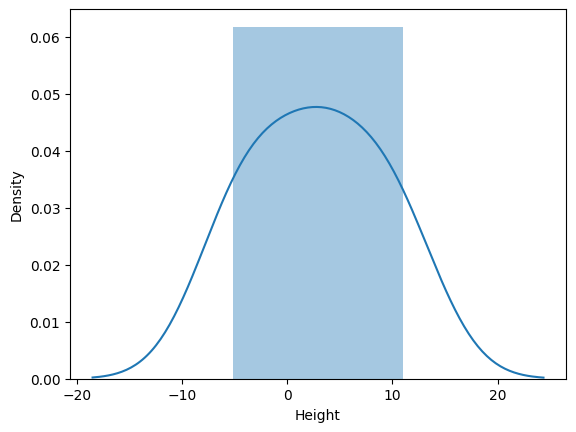

In [51]:
import seaborn as sns

sns.distplot(error, kde=True)

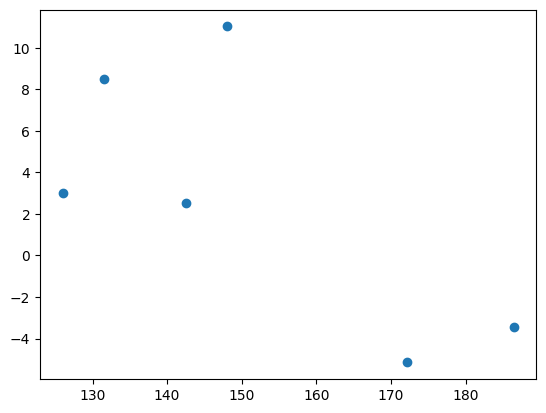

In [52]:
# error should have constant variance
plt.scatter(y_pred_test,error)